# tiny-yolov3-visdrone sur visdrone — balayage lot × sous-ensemble

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/visdrone/tiny-yolov3-visdrone_sweep.ipynb)

Rôle : balayage lot × sous-ensemble ; palier **N** (6 runs de 600 itérations par défaut) ; chaque run est évalué sur `SUBSET` images, puis comparé aux autres. Tâches : [T11.5](../../docs/tasks/M11-jeux-de-donnees.md), [T14.10](../../docs/tasks/M14-notebooks.md) ;
notebooks : [M14](../../docs/tasks/M14-notebooks.md).

Prérequis :
- données : `data/visdrone/VisDrone2019-DET-val/annotations` — tools/get_datasets.sh visdrone (inscription : source affichée)
- poids : `weights/yolov3-tiny.weights` — tools/get_weights.sh

Chaque étape affiche la commande `python tools/…` qu'elle lance : un résultat se
reproduit en ligne de commande. Sorties dans `build/notebooks/visdrone/tiny-yolov3-visdrone/`, jamais dans `results/`
(une mAP sur `SUBSET` images n'est pas publiable, règles de M12). Notebook généré par
`python -m tools.notebooks` (`make notebooks`) : modifier le gabarit
`tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [32]:
NET           = 'build/m11/cfg/tiny-yolov3-visdrone.cfg'  # nom de CFG_FILES ou cfg (relative à la racine)
DATASET       = 'visdrone'  # clé de DATASETS
SPLIT         = None  # None : split d'évaluation du jeu
WEIGHTS       = None  # par run : OUT/runs/<run>/final.weights
DEVICE        = 'gpu'  # cpu | gpu (entraînement seulement ; le reste sur CPU)
SUBSET        = 50  # images évaluées ; 0 : split complet (palier N)
SIZE          = None  # entrée LxH (ex. '640x192') ; None : celle de la cfg
RESIZE        = 'stretch'  # stretch (référence M12) | letterbox
METRIC        = None  # None : celle du jeu (coco pour coco et flir)
DATA_ROOT     = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
BASE          = 'tiny-yolov3-voc'  # base de make_cfg.py
CHANNELS      = None  # canaux de la cfg (1 : thermique)
ANCHORS_K     = 6  # ancres de la cfg (6 : Tiny-YOLOv3)
INIT          = 'coco'  # coco | he | chemin d'un .weights
INIT_NET      = None  # réseau des poids de INIT s'il diffère de NET
BATCHES       = [8, 16, 32]  # tailles de lot essayées
TRAIN_SUBSETS = [500, 0]  # images d'entraînement (n premières) ; 0 : tout le split
ITERS         = 600  # itérations par run (palier N dès 600)
SKIP_DONE     = True  # saute les runs qui ont déjà final.weights
LR            = 0.001
BURN_IN       = 500
MULTISCALE    = True  # 320-608 tous les 10 lots
SAVE_EVERY    = None  # None : défaut de train.py (200)
WORKERS       = 4
DRIVE_DIR     = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar, sorties et reprise dans runs/ ; None : pas de Drive
JOBS          = 4  # processus des évaluations
SHOW          = 6  # images affichées
OUT           = 'build/notebooks/visdrone/tiny-yolov3-visdrone'  # sorties du notebook
REPO_URL      = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV           = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [33]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, INIT if str(INIT).endswith('.weights') else 'weights/yolov3-tiny.weights' if INIT == 'coco' else (), None, DATA_ROOT, COLAB, hint='',
            drive_dir=DRIVE_DIR)
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /content/EmbeddedComputervision @ 1a967f4 ; Python 3.13.15 ; NumPy 2.1.3 ; backend gpu
GPU : 1 visible(s), CuPy 14.0.1
données visdrone : data/visdrone/VisDrone2019-DET-val/annotations ; poids : weights/yolov3-tiny.weights


## Préparation (jeux hors VOC)

Ancres k-means sur le split d'entraînement (`tools/kmeans_anchors.py`, table dans
`OUT`), puis cfg à N classes (`tools/make_cfg.py`), comme `tools/m11.sh <jeu>-prep`.
Sautée si la cfg existe déjà.

In [34]:
import csv
import json

import numpy as np
from IPython.display import Markdown, display
from PIL import Image

from tools.detect import draw
from tools.notebooks.matrice import estimate
from yolo.data import datasets
from yolo.data.letterbox import input_size, parse_size, size_label
from yolo.models.tiny_yolo import load_cfg

if not str(NET).endswith(".cfg"):
    print(f"{NET} : cfg du dépôt, pas de préparation")
elif Path(NET).exists():
    print(f"{NET} existe : préparation sautée")
else:
    anchors = Path(OUT) / f"anchors_{DATASET}{'_' + str(SIZE) if SIZE else ''}.md"
    C.run(C.cmd_anchors(DATASET, SIZE, anchors, DATA_ROOT))
    C.run(C.cmd_make_cfg(BASE, DATASET, C.anchors_k(anchors, ANCHORS_K), NET, SIZE,
                         CHANNELS))

build/m11/cfg/tiny-yolov3-visdrone.cfg existe : préparation sautée


## Aperçu des cibles

Quelques images augmentées (`yolo.data.loader.VOCDataset`, donc `yolo.data.augment`)
avec leurs boîtes : contrôle des annotations avant des heures de calcul.

6471 images d'entraînement, entrée 416×416, 3 canal(aux)


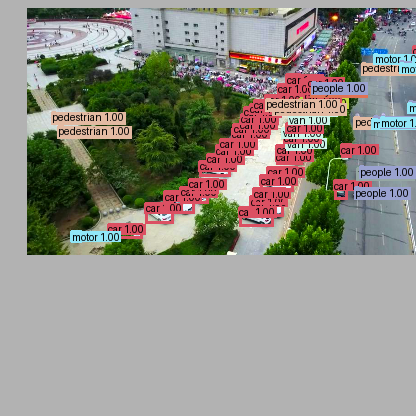

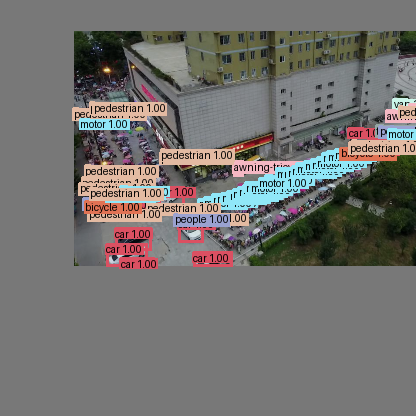

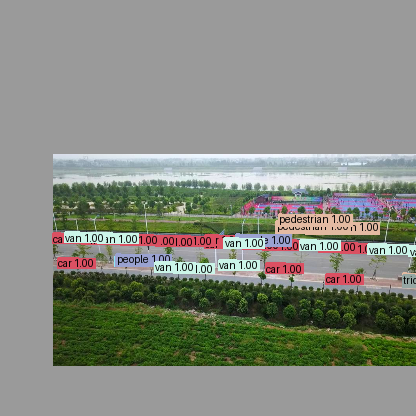

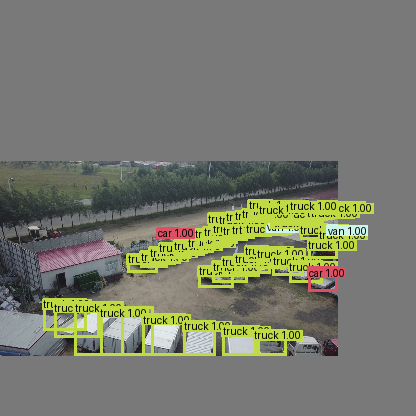

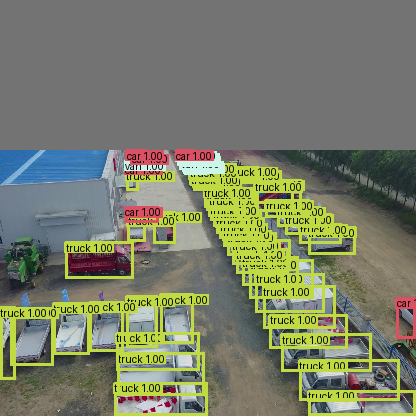

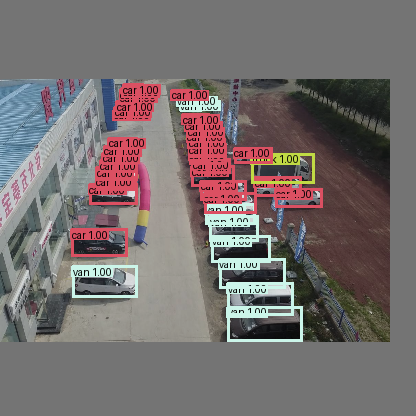

In [35]:
cfg = load_cfg(NET)
size = input_size(cfg, parse_size(SIZE) if SIZE else None)
channels = cfg["input"][0]
names = datasets.DATASETS[DATASET].classes
samples = datasets.load(DATASET, DATA_ROOT, role="train")
print(f"{len(samples)} images d'entraînement, entrée {size_label(size)}, {channels} canal(aux)")
from yolo.data.loader import VOCDataset

preview = VOCDataset(samples[:SHOW], train=True, channels=channels)
for k in range(len(preview)):
    chw, boxes, labels = preview.load(k, size, np.random.default_rng(k))
    hwc = (np.clip(chw.transpose(1, 2, 0), 0, 1) * 255).astype(np.uint8)
    img = Image.fromarray(hwc[..., 0] if channels == 1 else hwc)
    display(draw(img, boxes, np.ones(len(labels)), labels, names))

## Plan du balayage (T14.10)

Un run par case de la grille `BATCHES × TRAIN_SUBSETS`, tous les autres paramètres
égaux (ceux de `tools/m11.sh <jeu>-train`, `ITERS` à part). `TRAIN_SUBSETS` prend les
n premières images du split d'entraînement (`train.py --subset`), 0 tout le split.
À itérations égales, un lot plus grand voit plus d'images : la colonne « époques »
le montre. Le taux d'apprentissage n'est pas ajusté au lot.

In [36]:
import threading

from tools.notebooks import colab, runs

PLAN = [(b, s, runs.run_name(b, s)) for b in BATCHES for s in TRAIN_SUBSETS]
rows = ["| run | lot | images | époques | durée estimée |", "|---|---|---|---|---|"]
total = 0
for b, s, name in PLAN:
    n = min(s, len(samples)) if s else len(samples)
    sec = estimate(ITERS, b, DEVICE)
    total += sec or 0
    done = (Path(OUT) / "runs" / name / "final.weights").exists()
    rows.append(f"| {name}{' (fait)' if done else ''} | {b} | {n} | "
                f"{ITERS * b / n:.2f} | "
                + (f"{sec / 3600:.1f} h |" if sec else "non mesurée |"))
display(Markdown("\n".join(rows)))
print(f"{len(PLAN)} runs de {ITERS} itérations"
      + (f", ≈ {total / 3600:.1f} h sur {DEVICE} au total" if total else ""))

| run | lot | images | époques | durée estimée |
|---|---|---|---|---|
| b8-s500 (fait) | 8 | 500 | 9.60 | non mesurée |
| b8-sall (fait) | 8 | 6471 | 0.74 | non mesurée |
| b16-s500 (fait) | 16 | 500 | 19.20 | non mesurée |
| b16-sall | 16 | 6471 | 1.48 | non mesurée |
| b32-s500 | 32 | 500 | 38.40 | non mesurée |
| b32-sall | 32 | 6471 | 2.97 | non mesurée |

6 runs de 600 itérations


## Entraînements

Chaque run va dans `OUT/runs/<run>/` (`b16-sall`, `b8-s500`…), avec son `run.json`.
Relancer la cellule reprend le run interrompu (`--resume`) et saute ceux qui sont
finis (`SKIP_DONE`). Sur Colab avec `DRIVE_DIR`, `OUT` est copié dans
`<DRIVE_DIR>/runs/` toutes les 10 min et en fin de cellule (T14.8).

In [37]:
SYNC = COLAB and bool(DRIVE_DIR)
if SYNC:
    env.mount_drive(DRIVE_DIR)
    colab.restore_outputs(OUT, DRIVE_DIR)
stop = threading.Event()


def sync_loop(every=600):
    while not stop.wait(every):
        colab.sync_outputs(OUT, DRIVE_DIR)


if SYNC:
    threading.Thread(target=sync_loop, daemon=True).start()
try:
    for b, s, name in PLAN:
        run_dir = Path(OUT) / "runs" / name
        if SKIP_DONE and (run_dir / "final.weights").exists():
            print(f"{name} : déjà entraîné, sauté")
            continue
        resume = (run_dir / "checkpoint.npz").exists()
        runs.write_meta(run_dir, batch=b, subset=s, iters=ITERS, lr=LR, device=DEVICE,
                        net=NET, dataset=DATASET, rev=TRACE["rev"])
        C.run(C.cmd_train(NET, run_dir, DATASET, INIT, INIT_NET, resume, iters=ITERS,
                          batch=b, lr=LR, burn_in=BURN_IN, multiscale=MULTISCALE,
                          subset=s, save_every=SAVE_EVERY, workers=WORKERS,
                          device=DEVICE, data_root=DATA_ROOT),
              log=run_dir / "log.txt")
finally:
    stop.set()
    if SYNC:
        colab.sync_outputs(OUT, DRIVE_DIR)

/content/drive/MyDrive/EmbeddedCV/runs/build/notebooks/visdrone/tiny-yolov3-visdrone → build/notebooks/visdrone/tiny-yolov3-visdrone
b8-s500 : déjà entraîné, sauté
b8-sall : déjà entraîné, sauté
b16-s500 : déjà entraîné, sauté
$ python tools/train.py --net build/m11/cfg/tiny-yolov3-visdrone.cfg --dataset visdrone --init coco --resume --iters 600 --batch 16 --lr 0.001 --burn-in 500 --multiscale --workers 4 --device gpu --out build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-sall
reprise à l'itération 200
backend : gpu
6471 images, 404 lots par époque
it    201  lr 2.61e-05  perte  387.954  coord 63.216 obj 128.034 noobj 51.536 cls 145.167
it    202  lr 2.66e-05  perte  287.777  coord 46.503 obj 90.083 noobj 50.698 cls 100.493
it    203  lr 2.72e-05  perte  284.864  coord 40.233 obj 88.597 noobj 53.222 cls 102.811
it    204  lr 2.77e-05  perte  374.963  coord 63.583 obj 126.952 noobj 43.493 cls 140.934
it    205  lr 2.83e-05  perte  289.815  coord 44.502 obj 90.832 noobj 47.223 cls 

## Comparaison

mAP flottante de chaque run sur les mêmes `SUBSET` images (`tools/eval_voc.py`,
réutilisée si déjà calculée), perte finale et vitesse ; courbes de perte superposées
(`tools.figures.resultats.plot_training`, M13). Les notebooks d'inférence
`<modèle>_infer` lisent ces runs (`RUN`, `COMPARE`).

$ python tools/eval_voc.py --net build/m11/cfg/tiny-yolov3-visdrone.cfg --weights build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-s500/final.weights --dataset visdrone --resize stretch --subset 50 --out build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-s500/dets_s50 --markdown build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-s500/map_float_s50.md
50/50 images      15 s  (292 ms/image)
détections : build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-s500/dets_s50
### build/m11/cfg/tiny-yolov3-visdrone.cfg (final.weights), visdrone val, 50 images, 416×416 stretch (pil), conf 0.005, NMS 0.45, AP 11 points

| Classe | AP |
|---|---|
| pedestrian | 0.4 |
| people | 0.6 |
| bicycle | 0.0 |
| car | 9.7 |
| van | 0.0 |
| truck | 0.2 |
| tricycle | 0.3 |
| awning-tricycle | 0.8 |
| bus | 0.0 |
| motor | 1.5 |
| **mAP** | **1.35** |

figures : build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-s500/dets_s50/figures/pr.png
  (19 s)
$ python tools/eval_voc.py --net build/m

| run | lot | images | itérations | backend | perte finale | mAP | s/image | éval. |
|---|---|---|---|---|---|---|---|---|
| b32-sall | 32 | tout | 600 | gpu | 185.96 | 2.24 | 0.04 | 50 |
| b16-s500 | 16 | 500 | 600 | gpu | 220.65 | 1.35 | 0.04 | 50 |
| b8-sall | 8 | tout | 600 | gpu | 208.68 | 1.24 | 0.04 | 50 |
| b16-sall | 16 | tout | 600 | gpu | 203.54 | 1.15 | 0.04 | 50 |
| b32-s500 | 32 | 500 | 600 | gpu | 200.33 | 0.78 | 0.04 | 50 |
| b8-s500 | 8 | 500 | 600 | gpu | 252.11 | 0.56 | 0.04 | 50 |

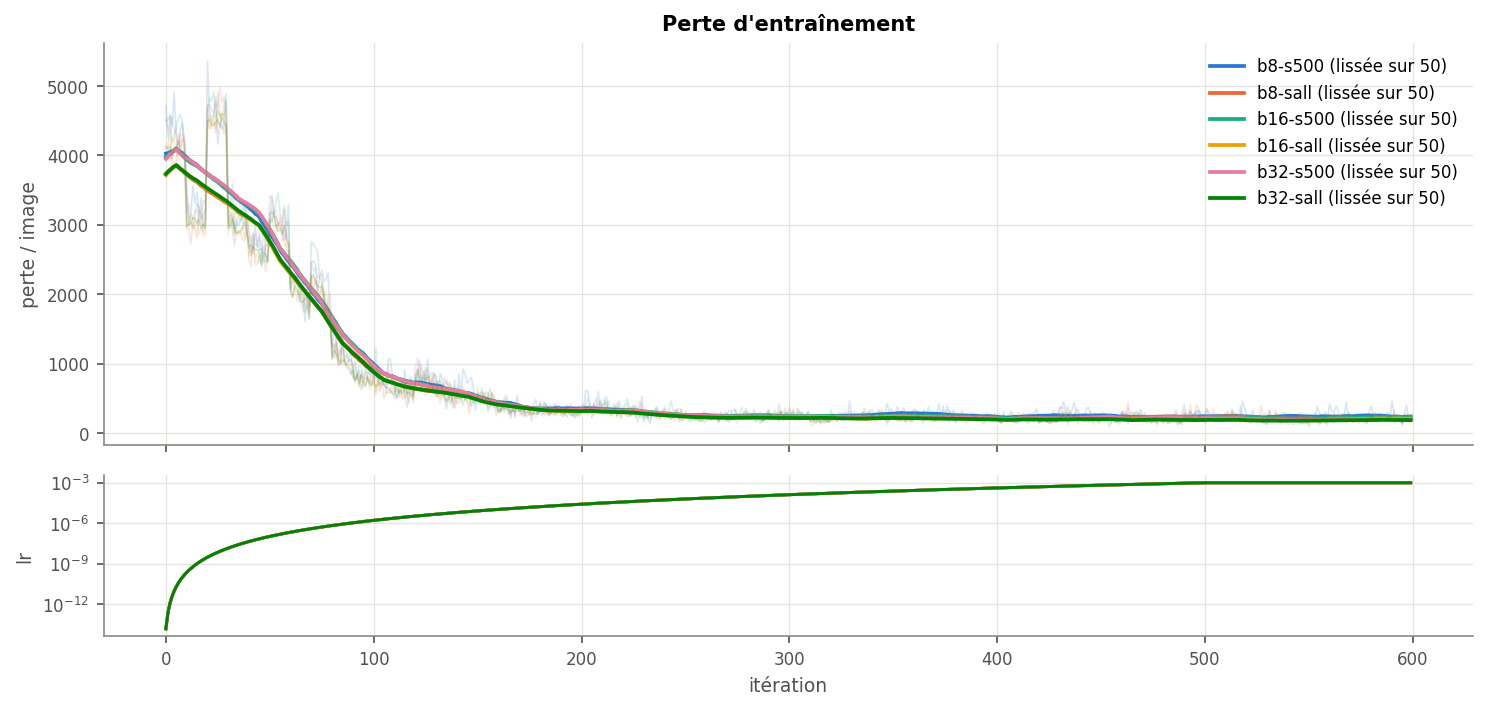

In [38]:
from tools.figures import MissingSource
from tools.figures import resultats as FR

RESULTS = [runs.evaluate(r, NET, DATASET, RESIZE, SUBSET, METRIC, SPLIT, SIZE, DATA_ROOT)
           for r in runs.find_runs(OUT) if r.name != runs.TRAIN]
display(Markdown(runs.table(RESULTS)))
curves = []
for b, s, name in PLAN:
    try:
        curves.append(FR.load_training(Path(OUT) / "runs" / name))
    except MissingSource:
        pass
if curves:
    for png in FR.plot_training(curves, Path(OUT) / "figures", "balayage"):
        if str(png).endswith(".png"):
            display(Image.open(png))

## Résumé

In [39]:
print(f"runs : {OUT}/runs/ ; backend {DEVICE} ; révision {TRACE['rev']}")
best = max((r for r in RESULTS if r["mAP"] is not None), key=lambda r: r["mAP"],
           default=None)
if best:
    print(f"meilleur run sur {SUBSET or 'toutes les'} images : {best['run']} "
          f"(mAP {best['mAP']:.2f}) ; inférence : RUN = {best['run']!r}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

runs : build/notebooks/visdrone/tiny-yolov3-visdrone/runs/ ; backend gpu ; révision 1a967f4
meilleur run sur 50 images : b32-sall (mAP 2.24) ; inférence : RUN = 'b32-sall'
commandes équivalentes :
  python tools/train.py --net build/m11/cfg/tiny-yolov3-visdrone.cfg --dataset visdrone --init coco --resume --iters 600 --batch 16 --lr 0.001 --burn-in 500 --multiscale --workers 4 --device gpu --out build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b16-sall
  python tools/train.py --net build/m11/cfg/tiny-yolov3-visdrone.cfg --dataset visdrone --init coco --iters 600 --batch 32 --lr 0.001 --burn-in 500 --multiscale --subset 500 --workers 4 --device gpu --out build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b32-s500
  python tools/train.py --net build/m11/cfg/tiny-yolov3-visdrone.cfg --dataset visdrone --init coco --iters 600 --batch 32 --lr 0.001 --burn-in 500 --multiscale --workers 4 --device gpu --out build/notebooks/visdrone/tiny-yolov3-visdrone/runs/b32-sall
  python tools/eval_voc.p